# Mutation Analysis Demo

Demonstration of mutation ΔΔG analysis with the **empirical** scorer (the default
backend — fast, no molecular dynamics) and experimental validation.

This notebook shows how to:
1. Run a single mutation and compare to experiment (with build-averaging spread)
2. Run a batch of mutations and compute R²/RMSE/MAE vs literature ΔΔG
3. Visualize results with publication-ready plots
4. Perform position scanning with heatmap visualization
5. Conduct alanine scanning to identify hotspot residues

**Backend.** This demo uses `EmpiricalScorer` (FoldX-style, no MD): it builds the
mutant with PDBFixer, repacks the mutated side chain, and scores a local shell.
For the OpenMM physics reference instead, see `MutationEngine.mutate`
(`method="openmm"` on the `Sicifus` wrappers).

**Test System:** Barnase (1BNI)
- Small, stable bacterial ribonuclease
- Extensively studied for protein stability
- Rich experimental mutagenesis data

**Experimental Data Source:**
Serrano, L., Kellis, J.T., Cann, P., Matouschek, A., & Fersht, A.R. (1993).
"Step-wise Mutation of Barnase to Binase"
*J. Mol. Biol.* 233, 305-312.

**Requirements:**
- PDBFixer + OpenMM (for structure building, used by both backends):
  `pip install sicifus[energy]`

**Download test structure:**
```bash
curl -o 1BNI.pdb https://files.rcsb.org/download/1BNI.pdb
```

## Setup

Import required modules and download the Barnase structure.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sicifus import MutationEngine, EmpiricalScorer, Mutation
from sicifus.mutate import ALL_AMINO_ACIDS
from sicifus.visualization import plot_ddg, plot_position_scan_heatmap, plot_alanine_scan

# Build structures with the engine (PDBFixer); score with the empirical scorer (no MD).
engine = MutationEngine()
scorer = EmpiricalScorer()


def empirical_ddg(pdb, mutations, chain="A", n_builds=3, radius=8.0):
    """Empirical ΔΔG averaged over independent builds. Returns (mean, std, last_result)."""
    ddgs, last = [], None
    for _ in range(n_builds):
        wt_pdb, mut_pdb = engine.build_pdb_pair(pdb, mutations, chain=chain)
        last = scorer.score_mutation(wt_pdb, mut_pdb, mutations, chain=chain, radius=radius)
        ddgs.append(list(last.ddg.values())[0])
    return float(np.mean(ddgs)), float(np.std(ddgs)), last


def scan(pdb, chain, positions, targets, n_builds=1):
    """Generic empirical scan: ``targets(wt_resn)`` -> list of mutant 3-letter codes."""
    residues = engine.show_residues(pdb, chain=chain)
    wt_by_pos = {r["position"]: r["residue_name"] for r in residues.iter_rows(named=True)}
    rows = []
    for pos in positions:
        wt = wt_by_pos.get(pos)
        if wt is None:
            continue
        for mut in targets(wt):
            if mut == wt:
                continue
            m = Mutation(chain=chain, position=pos, wt_residue=wt, mut_residue=mut)
            ddg, _, _ = empirical_ddg(pdb, [m], chain=chain, n_builds=n_builds)
            rows.append({"chain": chain, "position": pos, "wt_residue": wt,
                         "mut_residue": mut, "ddg_kcal_mol": round(ddg, 4)})
    return pl.DataFrame(rows)

In [2]:
# Download and clean Barnase structure
import urllib.request
from pathlib import Path

if not Path("1BNI.pdb").exists():
    print("Downloading Barnase structure (1BNI) from RCSB...")
    urllib.request.urlretrieve("https://files.rcsb.org/download/1BNI.pdb", "1BNI_raw.pdb")
    
    print("Cleaning structure (removing waters and heteroatoms)...")
    with open("1BNI_raw.pdb", "r") as f_in, open("1BNI.pdb", "w") as f_out:
        for line in f_in:
            # Keep only ATOM records (skip HETATM for waters, ligands)
            if line.startswith("ATOM"):
                f_out.write(line)
            # Keep structural records
            elif line.startswith(("MODEL", "ENDMDL", "END", "TER")):
                f_out.write(line)
    
    print("✅ Downloaded and cleaned 1BNI.pdb")
else:
    print("Using existing 1BNI.pdb")

Using existing 1BNI.pdb


## Demo 1: Single Mutation

Run a single mutation (H18K - Histidine to Lysine at position 18).

**Experimental value:** H18K has ΔΔG = +1.19 kcal/mol (Serrano et al. 1993, Table 3)
- Destabilizing mutation (His to Lys in α-helix 1)
- Located in first α-helix

The empirical backend has no minimisation, so we instead average over a few
independent **builds** (`n_builds`); the spread (std) across builds reports the
sensitivity to side-chain placement.

In [3]:
# Empirical ΔΔG for H18K, averaged over 5 builds
ddg_mean, ddg_std, result = empirical_ddg("1BNI.pdb", ["H18K"], n_builds=5)

In [4]:
# Display results
label = "H18K"
print(f"Mutation: {label}")
print(f"Wild-type energy:    {result.wt_energy:.2f} kcal/mol")
print(f"Mutant energy:       {result.mutant_energies[label]:.2f} kcal/mol")
print(f"ΔΔG (mean of builds): {ddg_mean:+.2f} ± {ddg_std:.2f} kcal/mol")
print()

# Per-term breakdown (shell-restricted, weighted)
print("Energy term breakdown:")
print(result.energy_terms)
print()

# Compare to experiment
experimental_ddg = 1.19
error = ddg_mean - experimental_ddg

print("Comparison to Experiment:")
print(f"  Experimental ΔΔG: {experimental_ddg:+.2f} kcal/mol (Serrano et al. 1993)")
print(f"  Predicted ΔΔG:    {ddg_mean:+.2f} kcal/mol")
print(f"  Error:            {error:+.2f} kcal/mol")
print(f"  Absolute error:   {abs(error):.2f} kcal/mol")

Mutation: H18K
Wild-type energy:    18.57 kcal/mol
Mutant energy:       19.32 kcal/mol
ΔΔG (mean of builds): +0.69 ± 0.03 kcal/mol

Energy term breakdown:
shape: (9, 4)
┌────────────┬───────────┬───────────────┬─────────┐
│ term       ┆ wt_energy ┆ mutant_energy ┆ delta   │
│ ---        ┆ ---       ┆ ---           ┆ ---     │
│ str        ┆ f64       ┆ f64           ┆ f64     │
╞════════════╪═══════════╪═══════════════╪═════════╡
│ vdw        ┆ -31.903   ┆ -31.5982      ┆ 0.3048  │
│ clash      ┆ 36.3622   ┆ 36.3796       ┆ 0.0174  │
│ solvH      ┆ 0.4885    ┆ 0.3712        ┆ -0.1173 │
│ solvP      ┆ -0.4369   ┆ -0.4107       ┆ 0.0262  │
│ hbond      ┆ -0.0      ┆ -0.0          ┆ 0.0     │
│ elec       ┆ 0.0       ┆ 0.0           ┆ 0.0     │
│ mc_entropy ┆ 4.5798    ┆ 4.5798        ┆ 0.0     │
│ sc_entropy ┆ 9.4784    ┆ 9.9985        ┆ 0.5201  │
│ total      ┆ 18.5691   ┆ 19.3202       ┆ 0.7511  │
└────────────┴───────────┴───────────────┴─────────┘

Comparison to Experiment:
  Experim

**Interpretation:**
- **ΔΔG > 0**: Mutation destabilizes the protein (unfavorable)
- **ΔΔG < 0**: Mutation stabilizes the protein (favorable)
- **Small build-to-build std**: prediction is robust to side-chain placement
- **Error < 1 kcal/mol**: acceptable prediction accuracy for an empirical scorer

## Demo 2: Batch Mutations with Experimental Validation

Run a set of well-characterized Barnase mutations and compare to experimental values.

**Dataset:** Mutations from Serrano et al. (1993) - *J Mol Biol* 233:305-312, Table 3
- These are single-point mutations at various positions
- Experimental ΔΔG measured by urea denaturation
- Temperature: 25°C, pH: 6.3

In [5]:
# Define mutations with experimental data from Serrano et al. (1993), Table 3
mutations_df = pl.DataFrame({
    "mutation": ["H18K", "I55V", "K62R", "K66A", "T79V", "S85A", "I88L", "L89V"],
    "chain": ["A"] * 8,
    "experimental_ddg": [1.19, 0.29, 0.48, -0.25, -0.29, 0.12, 0.28, 0.27],
    "location": ["α-helix 1", "β-strand 1", "Loop", "α-helix 2", "Loop", "Loop", "β-strand 3", "β-strand 3"],
    "notes": [
        "His to Lys - destabilizing",
        "Ile to Val - smaller hydrophobic",
        "Lys to Arg - guanosine binding loop",
        "Lys to Ala - stabilizing",
        "Thr to Val - stabilizing",
        "Ser to Ala - slight destabilizing",
        "Ile to Leu - conservative",
        "Leu to Val - conservative"
    ]
})

print("Mutations to analyze:")
mutations_df.select(["mutation", "experimental_ddg", "location", "notes"])

Mutations to analyze:


mutation,experimental_ddg,location,notes
str,f64,str,str
"""H18K""",1.19,"""α-helix 1""","""His to Lys - destabilizing"""
"""I55V""",0.29,"""β-strand 1""","""Ile to Val - smaller hydrophob…"
"""K62R""",0.48,"""Loop""","""Lys to Arg - guanosine binding…"
"""K66A""",-0.25,"""α-helix 2""","""Lys to Ala - stabilizing"""
"""T79V""",-0.29,"""Loop""","""Thr to Val - stabilizing"""
"""S85A""",0.12,"""Loop""","""Ser to Ala - slight destabiliz…"
"""I88L""",0.28,"""β-strand 3""","""Ile to Leu - conservative"""
"""L89V""",0.27,"""β-strand 3""","""Leu to Val - conservative"""


In [6]:
# Run empirical ΔΔG for each mutation (no MD — seconds each)
print("Running empirical ΔΔG for each mutation...\n")

rows = []
for r in mutations_df.iter_rows(named=True):
    mean, std, _ = empirical_ddg("1BNI.pdb", [r["mutation"]], chain=r["chain"], n_builds=3)
    rows.append({**r, "predicted_ddg": round(mean, 4), "ddg_sd": round(std, 4)})
    print(f"  {r['mutation']}: {mean:+.2f} ± {std:.2f}  (exp {r['experimental_ddg']:+.2f})")

results_df = pl.DataFrame(rows)

print("\nResults:")
results_df.select(["mutation", "experimental_ddg", "predicted_ddg", "location"])

Running empirical ΔΔG for each mutation...



  H18K: +0.76 ± 0.08  (exp +1.19)


  I55V: +0.25 ± 0.03  (exp +0.29)


  K62R: +0.07 ± 0.35  (exp +0.48)


  K66A: -0.63 ± 0.03  (exp -0.25)


  T79V: -0.07 ± 0.01  (exp -0.29)


  S85A: -0.15 ± 0.04  (exp +0.12)


  I88L: +0.12 ± 0.10  (exp +0.28)


  L89V: +0.57 ± 0.17  (exp +0.27)

Results:


mutation,experimental_ddg,predicted_ddg,location
str,f64,f64,str
"""H18K""",1.19,0.7558,"""α-helix 1"""
"""I55V""",0.29,0.2467,"""β-strand 1"""
"""K62R""",0.48,0.0698,"""Loop"""
"""K66A""",-0.25,-0.633,"""α-helix 2"""
"""T79V""",-0.29,-0.0696,"""Loop"""
"""S85A""",0.12,-0.1502,"""Loop"""
"""I88L""",0.28,0.1246,"""β-strand 3"""
"""L89V""",0.27,0.5682,"""β-strand 3"""


### Calculate Prediction Metrics

In [7]:
# Extract arrays (excluding any NaN predictions)
valid_results = results_df.filter(~pl.col("predicted_ddg").is_nan())

experimental = valid_results["experimental_ddg"].to_numpy()
predicted = valid_results["predicted_ddg"].to_numpy()

# Calculate metrics
r_squared = stats.pearsonr(experimental, predicted)[0] ** 2
rmse = np.sqrt(np.mean((predicted - experimental) ** 2))
mae = np.mean(np.abs(predicted - experimental))
pearson_r, pearson_p = stats.pearsonr(experimental, predicted)

print("="*60)
print("PREDICTION PERFORMANCE")
print("="*60)
print(f"Sample size:       {len(experimental)} mutations")
print(f"R² (R-squared):    {r_squared:.3f}")
print(f"RMSE:              {rmse:.2f} kcal/mol")
print(f"MAE:               {mae:.2f} kcal/mol")
print(f"Pearson r:         {pearson_r:.3f} (p = {pearson_p:.2e})")
print("="*60)

# Interpretation
print("\nINTERPRETATION:")
if r_squared > 0.5:
    print(f"✅ Good correlation (R² = {r_squared:.3f})")
elif r_squared > 0.3:
    print(f"⚠️  Moderate correlation (R² = {r_squared:.3f})")
else:
    print(f"❌ Weak correlation (R² = {r_squared:.3f})")

if mae < 1.0:
    print(f"✅ Low MAE ({mae:.2f} kcal/mol - good accuracy)")
elif mae < 1.5:
    print(f"⚠️  Moderate MAE ({mae:.2f} kcal/mol - acceptable)")
else:
    print(f"❌ High MAE ({mae:.2f} kcal/mol - poor accuracy)")

print("\nContext: State-of-the-art methods typically achieve:")
print("  - R² ~ 0.4-0.7 for diverse mutations")
print("  - MAE ~ 0.8-1.2 kcal/mol")

PREDICTION PERFORMANCE
Sample size:       8 mutations
R² (R-squared):    0.639
RMSE:              0.30 kcal/mol
MAE:               0.28 kcal/mol
Pearson r:         0.799 (p = 1.73e-02)

INTERPRETATION:
✅ Good correlation (R² = 0.639)
✅ Low MAE (0.28 kcal/mol - good accuracy)

Context: State-of-the-art methods typically achieve:
  - R² ~ 0.4-0.7 for diverse mutations
  - MAE ~ 0.8-1.2 kcal/mol


### Detailed Comparison Table

In [8]:
# Add error column
comparison_df = valid_results.with_columns(
    (pl.col("predicted_ddg") - pl.col("experimental_ddg")).alias("error"),
    (pl.col("predicted_ddg") - pl.col("experimental_ddg")).abs().alias("abs_error")
)

print("Detailed Comparison:")
print()
comparison_df.select([
    "mutation", 
    "experimental_ddg", 
    "predicted_ddg", 
    "error", 
    "abs_error",
    "location"
]).sort("abs_error", descending=True)

Detailed Comparison:



mutation,experimental_ddg,predicted_ddg,error,abs_error,location
str,f64,f64,f64,f64,str
"""H18K""",1.19,0.7558,-0.4342,0.4342,"""α-helix 1"""
"""K62R""",0.48,0.0698,-0.4102,0.4102,"""Loop"""
"""K66A""",-0.25,-0.633,-0.383,0.383,"""α-helix 2"""
"""L89V""",0.27,0.5682,0.2982,0.2982,"""β-strand 3"""
"""S85A""",0.12,-0.1502,-0.2702,0.2702,"""Loop"""
"""T79V""",-0.29,-0.0696,0.2204,0.2204,"""Loop"""
"""I88L""",0.28,0.1246,-0.1554,0.1554,"""β-strand 3"""
"""I55V""",0.29,0.2467,-0.0433,0.0433,"""β-strand 1"""


### Visualization: Predicted vs Experimental Scatter Plot

Saved to barnase_validation.png


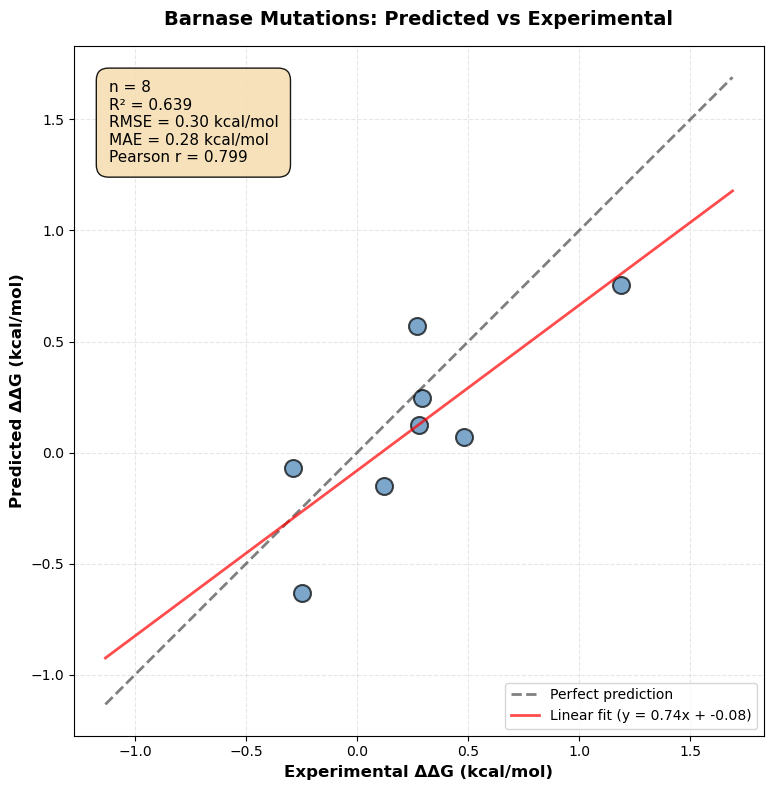

In [9]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
ax.scatter(experimental, predicted, alpha=0.7, s=150, 
           edgecolors='black', linewidth=1.5, c='steelblue')

# Perfect prediction line (y = x)
min_val = min(experimental.min(), predicted.min()) - 0.5
max_val = max(experimental.max(), predicted.max()) + 0.5
ax.plot([min_val, max_val], [min_val, max_val], 
        'k--', alpha=0.5, linewidth=2, label='Perfect prediction')

# Linear regression fit
slope, intercept = np.polyfit(experimental, predicted, 1)
fit_x = np.linspace(min_val, max_val, 100)
fit_y = slope * fit_x + intercept
ax.plot(fit_x, fit_y, 'r-', alpha=0.7, linewidth=2,
        label=f'Linear fit (y = {slope:.2f}x + {intercept:+.2f})')

# Labels
ax.set_xlabel('Experimental ΔΔG (kcal/mol)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted ΔΔG (kcal/mol)', fontsize=12, fontweight='bold')
ax.set_title('Barnase Mutations: Predicted vs Experimental',
             fontsize=14, fontweight='bold', pad=15)

# Statistics text box
stats_text = (
    f"n = {len(experimental)}\n"
    f"R² = {r_squared:.3f}\n"
    f"RMSE = {rmse:.2f} kcal/mol\n"
    f"MAE = {mae:.2f} kcal/mol\n"
    f"Pearson r = {pearson_r:.3f}"
)

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, pad=0.8))

# Formatting
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=10)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("barnase_validation.png", dpi=300, bbox_inches='tight')
print("Saved to barnase_validation.png")
plt.show()

### Visualize ΔΔG with Error Bars

Saved to barnase_comparison.png


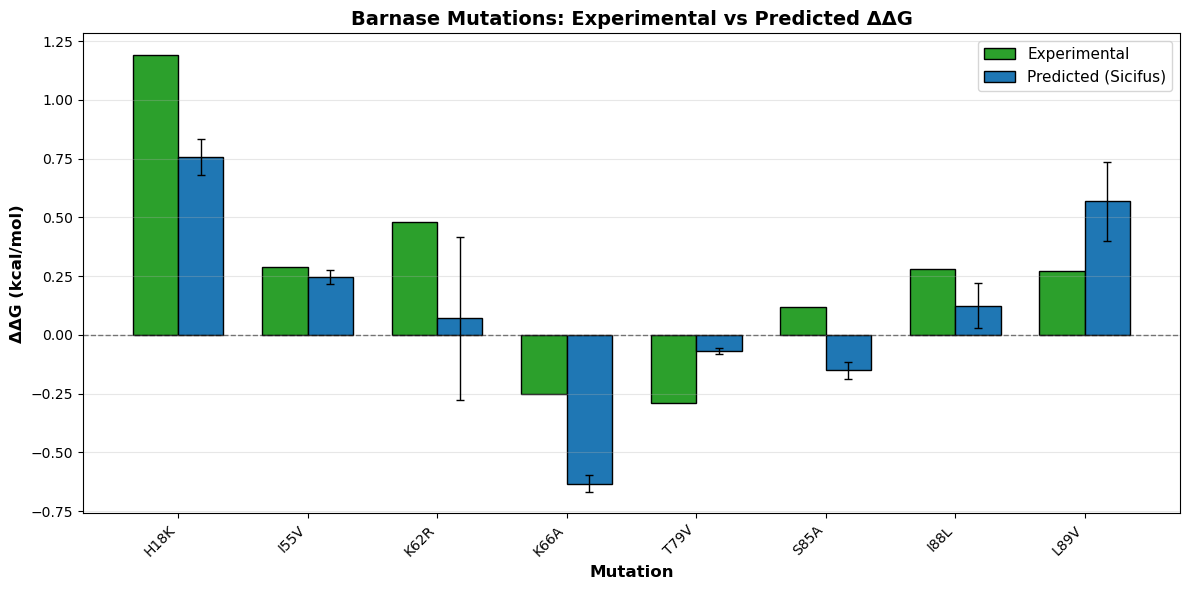

In [10]:
# Create bar chart with experimental comparison
fig, ax = plt.subplots(figsize=(12, 6))

mutations = comparison_df["mutation"].to_list()
exp_values = comparison_df["experimental_ddg"].to_numpy()
pred_values = comparison_df["predicted_ddg"].to_numpy()

x = np.arange(len(mutations))
width = 0.35

# Plot bars
bars1 = ax.bar(x - width/2, exp_values, width, label='Experimental',
               color='#2ca02c', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, pred_values, width, label='Predicted (Sicifus)',
               color='#1f77b4', edgecolor='black', linewidth=1)

# Add error bars if statistics available
if "ddg_sd" in comparison_df.columns:
    pred_sd = comparison_df["ddg_sd"].to_numpy()
    ax.errorbar(x + width/2, pred_values, yerr=pred_sd, 
                fmt='none', ecolor='black', capsize=3, linewidth=1)

# Formatting
ax.set_xlabel('Mutation', fontsize=12, fontweight='bold')
ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=12, fontweight='bold')
ax.set_title('Barnase Mutations: Experimental vs Predicted ΔΔG', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(mutations, rotation=45, ha='right')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("barnase_comparison.png", dpi=300, bbox_inches='tight')
print("Saved to barnase_comparison.png")
plt.show()

## Demo 3: Position Scan with Heatmap

Scan all 20 amino acids at selected positions to create a mutational landscape
(19 mutations per position). The empirical backend makes this cheap; here we scan
two positions with `n_builds=1` for speed.

In [11]:
# Scan positions 55 (Ile) and 56 (Phe) across all 20 amino acids
scan_df = scan(
    "1BNI.pdb",
    chain="A",
    positions=[55, 56],
    targets=lambda wt: ALL_AMINO_ACIDS,
    n_builds=1,
)

print(f"Completed {len(scan_df)} mutations")
print("\nSample results:")
scan_df.head(10)

Completed 38 mutations

Sample results:


chain,position,wt_residue,mut_residue,ddg_kcal_mol
str,i64,str,str,f64
"""A""",55,"""ILE""","""ALA""",0.3497
"""A""",55,"""ILE""","""ARG""",0.8717
"""A""",55,"""ILE""","""ASN""",0.3308
"""A""",55,"""ILE""","""ASP""",0.3569
"""A""",55,"""ILE""","""CYS""",0.804
"""A""",55,"""ILE""","""GLN""",0.7591
"""A""",55,"""ILE""","""GLU""",0.7024
"""A""",55,"""ILE""","""GLY""",0.6781
"""A""",55,"""ILE""","""HIS""",0.0982


In [12]:
# Create heatmap visualization
plot_position_scan_heatmap(
    scan_df,
    output_file="barnase_position_scan.png",
    cmap="RdBu_r",  # Red (destabilizing) to Blue (stabilizing)
    vmin=-2.0,
    vmax=3.0
)

print("Saved to barnase_position_scan.png")

Saved to barnase_position_scan.png


**Heatmap interpretation:**
- **Rows**: Mutant amino acid type (all 20 possibilities)
- **Columns**: Position in the protein
- **Color**: Red = destabilizing, Blue = stabilizing, White = neutral
- **Black boxes**: Wild-type residue at each position

**Expected patterns:**
- Position 55 (Ile) and 56 (Phe) are buried hydrophobic-core residues, so most
  substitutions — especially to polar or charged residues — should read as
  destabilizing (red), while conservative hydrophobic swaps are milder.

## Demo 4: Alanine Scan

Alanine scanning is a classic method to identify "hotspot" residues - positions where mutation to alanine significantly impacts stability.

In [13]:
# Alanine scan over positions 20-26 (averaged over 2 builds each)
scan_df = scan(
    "1BNI.pdb",
    chain="A",
    positions=list(range(20, 27)),
    targets=lambda wt: [] if wt in ("ALA", "GLY") else ["ALA"],
    n_builds=2,
).drop("mut_residue")

print("Alanine scan results (sorted by ddG):")
scan_df.sort("ddg_kcal_mol", descending=True)

Alanine scan results (sorted by ddG):


chain,position,wt_residue,ddg_kcal_mol
str,i64,str,f64
"""A""",24,"""TYR""",1.5096
"""A""",21,"""PRO""",0.6703
"""A""",25,"""ILE""",0.6437
"""A""",20,"""LEU""",0.5647
"""A""",23,"""ASN""",0.1092
"""A""",26,"""THR""",-0.0338
"""A""",22,"""ASP""",-0.1666


In [14]:
# Visualize with sorted bar chart
plot_alanine_scan(
    scan_df,
    output_file="barnase_alanine_scan.png",
    highlight_threshold=1.5  # Highlight if |ΔΔG| > 1.5 kcal/mol
)

print("Saved to barnase_alanine_scan.png")

Saved to barnase_alanine_scan.png


**Hotspot identification:**
- Positions with large positive ΔΔG are critical for stability
- Expected hotspots: Hydrophobic core residues (Ile, Leu, Val in buried regions)
- Compare to experimental: H18K = +1.19 kcal/mol (destabilizing when changed)

## Summary

This notebook demonstrated:

1. ✅ **Empirical ΔΔG** - fast, no-MD scoring (build + repack + shell)
2. ✅ **Experimental validation** - direct comparison to literature data
3. ✅ **Performance metrics** - R², RMSE, MAE to assess accuracy
4. ✅ **Comprehensive scanning** - position scans and alanine scans
5. ✅ **Publication plots** - heatmaps, bar charts, scatter plots

### Key Takeaways

- **Barnase is a good test system** - well-characterized, stable structure
- **The empirical backend is the default** - seconds per mutation; the OpenMM
  reference path is available with `method="openmm"`
- **Accuracy is calibration-dependent** - the shipped weights are a baseline
  (leave-one-out R ≈ 0.5); recalibrate with `examples/calibrate_empirical.py`
- **Build averaging reveals placement uncertainty** - `n_builds` + the per-term
  `delta_std`

### Next Steps

- Recalibrate weights on your own data: `examples/calibrate_empirical.py`
- Explore interface mutations: `interface_analysis_demo.ipynb`
- Larger validation dataset: `experimental_validation_demo.ipynb`
- Check the [documentation](https://arikat.github.io/sicifus) for advanced features

## Your Experiments

Use the cells below to experiment with your own structures and mutations:

In [15]:
# Your code here
